In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Настроим стиль графиков
sns.set(style="whitegrid")

In [18]:

df = pd.read_csv('./StudentPerformanceFactors.csv')
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


Данный датасет содержит информацию о различных факторах, влияющих на успеваемость студентов. Мы будем исследовать, как различные характеристики (например, социально-экономическое положение, время для учебы и т.д.) влияют на результаты.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

датасет 6607 rows × 20 columns. есть пропуски. природу пропусков нужно проверить. Пропуски есть только в колоках Teacher_Quality, Parental_Education_Level, Distance_from_Home. 
Возможные неконсистенности - отрицательные значения в int64, если это не подразумевается логикой, в тут во всех полях не подразумевается. Так же могут быть str чуть отличные по записи, либо с ошибкой, либо с большой буквы

In [4]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [5]:
df.isna().sum().sort_values(ascending=False)

Parental_Education_Level      90
Teacher_Quality               78
Distance_from_Home            67
Hours_Studied                  0
Attendance                     0
Gender                         0
Learning_Disabilities          0
Physical_Activity              0
Peer_Influence                 0
School_Type                    0
Family_Income                  0
Tutoring_Sessions              0
Internet_Access                0
Motivation_Level               0
Previous_Scores                0
Sleep_Hours                    0
Extracurricular_Activities     0
Access_to_Resources            0
Parental_Involvement           0
Exam_Score                     0
dtype: int64

пропусков около 1 процента, можем убрать, не критично (вообще на практике стоит посмотреть на корреляцию пропусков с таргетом, и решить что делать с ними)

In [14]:
df.dropna(inplace=True)
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [15]:
df.reset_index().drop(labels='index', axis=1)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6373,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6374,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6375,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6376,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


Быстро глазами проверим данные на консистентность

In [8]:
for collumn in df.select_dtypes(include=['str']).columns:
    print(df[collumn].unique())

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str
<StringArray>
['Public', 'Private']
Length: 2, dtype: str
<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['High School', 'College', 'Postgraduate']
Length: 3, dtype: str
<StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dtype: str
<StringArray>
['Male', 'Female']
Length: 2, dtype: str


Данные консистентны

### Визуализация данных

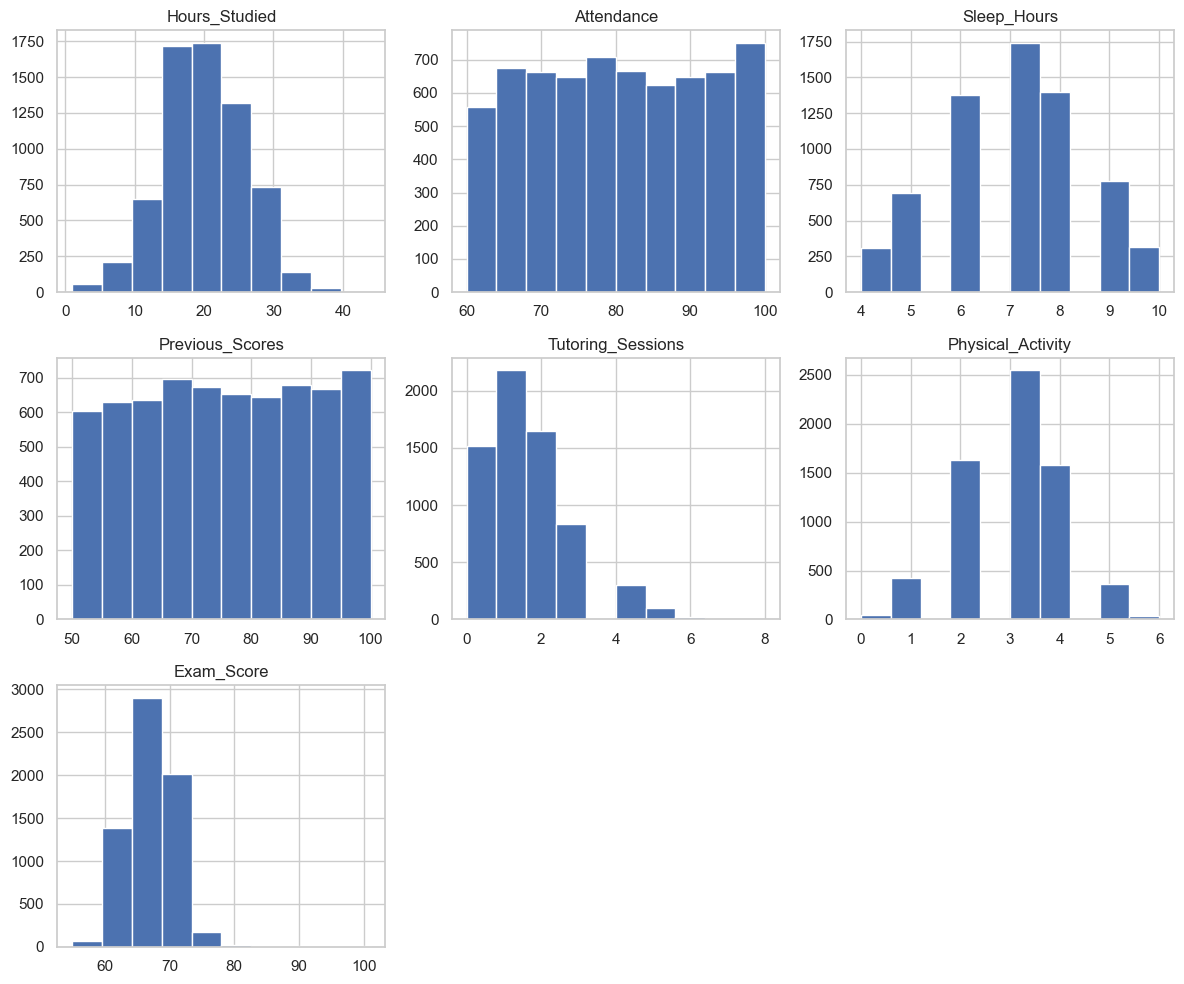

In [ ]:
# Гистограмма для всех числовых признаков
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

Выводы из гистограмм:

"Hours_Studied":
Время учебы распределено довольно равномерно, хотя больше всего студентов учат от 10 до 20 часов. Это указывает на то, что среднее количество часов учебы в день варьируется, но большинство студентов уделяют учебе разумное время.

"Attendance":
Большинство студентов имеют высокую посещаемость (в районе 70-90%), что подтверждает важность этого фактора для итоговых результатов.

"Sleep_Hours":
Часы сна студентов сосредоточены в диапазоне от 6 до 8 часов, что является оптимальным количеством сна для большинства.

"Previous_Scores":
Прежде чем начать текущий экзамен, большинство студентов имели баллы между 70 и 90, что указывает на достаточно хороший уровень подготовки у большинства.

"Tutoring_Sessions":
Большее количество студентов не посещает занятия с репетиторами или посещает их нечасто (от 0 до 2 раз). Это может означать, что репетиторство не является ключевым фактором для большинства студентов.

"Physical_Activity":
Большинство студентов ведут умеренно активный образ жизни (3 балла по шкале физической активности), что может оказывать слабое влияние на учебные результаты, как показано на тепловой карте.

"Exam_Score":
Распределение баллов по экзамену подтверждает, что большинство студентов набирают средние баллы (60-80), с небольшим количеством студентов с высокими или очень низкими баллами.

### Корреляция признаков

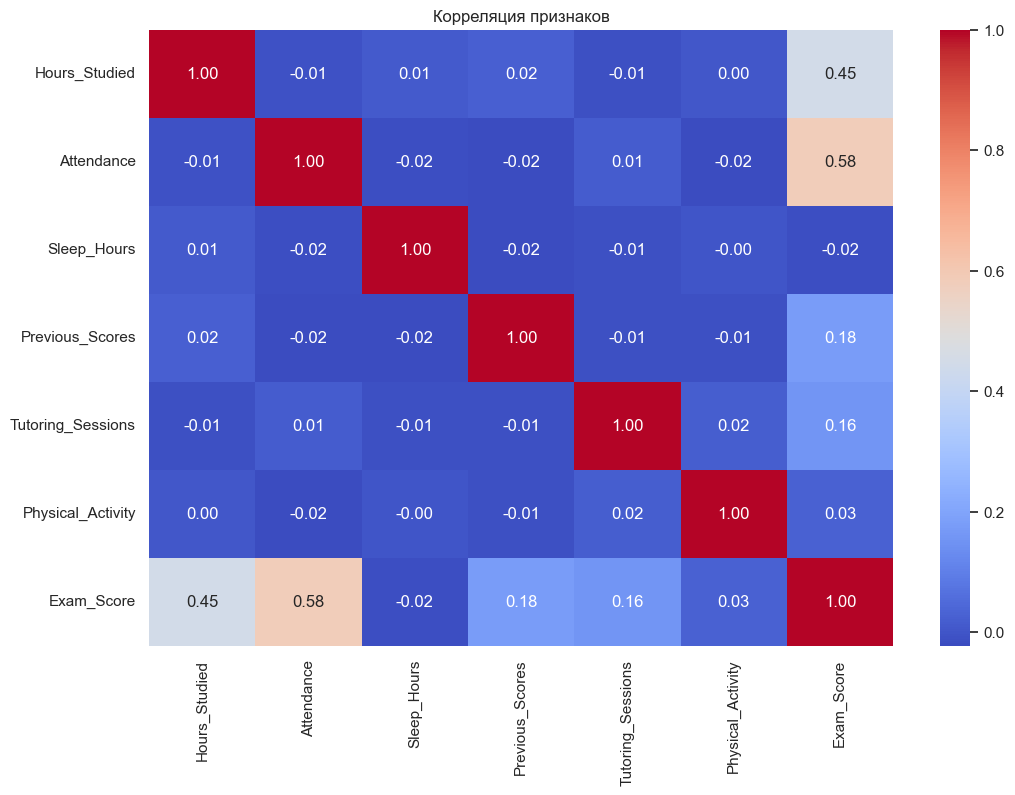

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляция признаков")
plt.show()

"Hours_Studied" и "Exam_Score" (0.45):
Существует умеренная положительная корреляция между часами учебы и оценкой на экзамене. Это логично, так как больше времени, потраченного на учебу, часто приводит к лучшим результатам.

"Attendance" и "Exam_Score" (0.58):
Также наблюдается умеренная положительная корреляция между посещаемостью и итоговой оценкой. Студенты, которые чаще посещают занятия, скорее всего, получают более высокие результаты.

"Previous_Scores" и "Exam_Score" (0.18):
Наблюдается слабая положительная корреляция между предыдущими баллами и экзаменационной оценкой. Это может означать, что предыдущие достижения студентов не сильно влияют на результаты текущего экзамена.

"Tutoring_Sessions" и "Exam_Score" (0.16):
Слабая положительная корреляция между количеством занятий с репетитором и результатами экзаменов. Возможно, влияние репетиторства на результат невелико, или же оно ограничено определенными категориями студентов.

"Physical_Activity" и "Exam_Score" (0.03):
Очень слабая или практически отсутствующая корреляция между физической активностью и результатами экзамена. Это может означать, что физическая активность не имеет прямого воздействия на экзаменационные баллы.

Гипотеза 1

Студенты, которые больше учатся, получают более высокий итоговый балл.

Text(0, 0.5, 'Exam_Score')

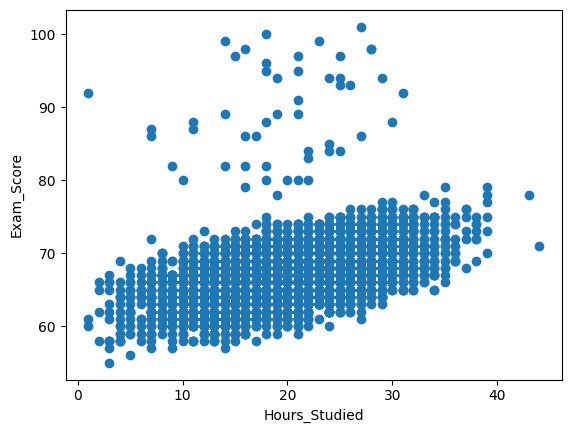

In [9]:
df['Hours_Studied'].nunique(), df['Exam_Score'].nunique()

plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel('Hours_Studied')
plt.ylabel('Exam_Score')

In [10]:
np.corrcoef(df['Hours_Studied'], df['Exam_Score'])[0, 1]

np.float64(0.4451041402651169)

Гипотеза 2

Студенты, состоящие в романтических отношениях, показывают худшие результаты.

In [11]:
grouped = df.groupby('Gender')['Exam_Score'].agg(func=['mean', 'median'])
grouped

,mean,median
Gender,,
Female,67.274721,67.0
Male,67.235629,67.0


In [12]:
grouped.index

Index(['Female', 'Male'], dtype='str', name='Gender')

1) цисла похожи, стат значимости нет, можем конечно проверить

<BarContainer object of 2 artists>

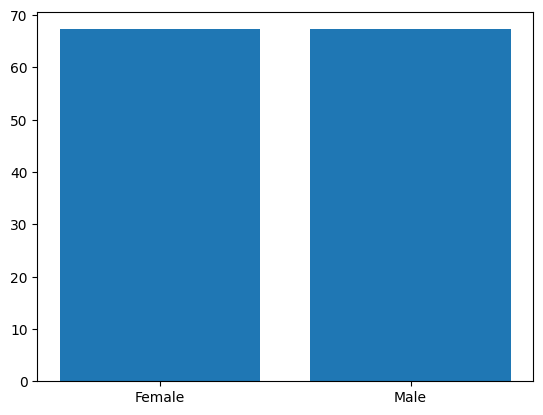

In [13]:
plt.bar(grouped.index, grouped['mean'])